In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
#Load dataset and run basic info summarization
df = pd.read_csv("/Users/huongle/Documents/GitHub/Mind_At_Work_Website/data/mind@work/mental heath dataset/Cleaned_remote_work.csv")
Impact_of_Remote_Work = df
def summarize_dataframe(Impact_of_Remote_Work, head_rows=5): 
    """ 
    Prints a summary of the DataFrame including: 
    - Head of the DataFrame 
    - Info of the DataFrame 
    - Description of the DataFrame 
    - Shape of the DataFrame
    Parameters:
    df (pd.DataFrame): The DataFrame to summarize 
    head_rows (int): The number of rows to show in the head (default is 5) 
    """ 
    print("### Head of DataFrame ###") 
    print(Impact_of_Remote_Work.head(head_rows)) 
    print("\n### Shape of DataFrame ###") 
    print(Impact_of_Remote_Work.shape) 
    print("\n### Info of DataFrame ###") 
    print(Impact_of_Remote_Work.info()) 
    print("\n### Description of DataFrame ###") 
    print(Impact_of_Remote_Work.describe())

summarize_dataframe(Impact_of_Remote_Work)

### Head of DataFrame ###
   Age      Gender           Job_Role    Industry  Years_of_Experience  \
0   32  Non-binary                 HR  Healthcare                   13   
1   40      Female     Data Scientist          IT                    3   
2   59  Non-binary  Software Engineer   Education                   22   
3   27        Male  Software Engineer     Finance                   20   
4   49        Male              Sales  Consulting                   32   

  Work_Location  Hours_Worked_Per_Week  Number_of_Virtual_Meetings  \
0        Hybrid                     47                           7   
1        Remote                     52                           4   
2        Hybrid                     46                          11   
3        Onsite                     32                           8   
4        Onsite                     35                          12   

   Work_Life_Balance_Rating Stress_Level Mental_Health_Condition  \
0                         2       Medium

In [7]:
df["Physical_Activity"] = df["Physical_Activity"].fillna("None")
df["Mental_Health_Condition"] = df["Mental_Health_Condition"].fillna("None")
# Confirm fixes
print(df.isna().sum())


Age                                  0
Gender                               0
Job_Role                             0
Industry                             0
Years_of_Experience                  0
Work_Location                        0
Hours_Worked_Per_Week                0
Number_of_Virtual_Meetings           0
Work_Life_Balance_Rating             0
Stress_Level                         0
Mental_Health_Condition              0
Access_to_Mental_Health_Resources    0
Productivity_Change                  0
Social_Isolation_Rating              0
Satisfaction_with_Remote_Work        0
Company_Support_for_Remote_Work      0
Physical_Activity                    0
Sleep_Quality                        0
Region                               0
dtype: int64


In [8]:
def summarize_unique_responses(Impact_of_Remote_Work, columns): 
    """ 
    Prints unique responses for specified columns in the DataFrame. 
    Parameters: 
    df (pd.DataFrame): The DataFrame to summarize 
    columns (list): List of column names to summarize unique responses 
    Example: summarize_unique_responses(df, ['Mental_Health_Condition', 'Stress_Level', 'Productivity_Change']) 
    """ 
    for column in columns: 
        unique_responses = Impact_of_Remote_Work[column].unique() 
        print(f"### {column} ###") 
        print(f"Unique responses: {len(unique_responses)}") 
        print(unique_responses) 
        print("\n")

summarize_unique_responses(Impact_of_Remote_Work, ['Mental_Health_Condition', 'Stress_Level', 'Productivity_Change'])  

### Mental_Health_Condition ###
Unique responses: 4
['Depression' 'Anxiety' 'None' 'Burnout']


### Stress_Level ###
Unique responses: 3
['Medium' 'High' 'Low']


### Productivity_Change ###
Unique responses: 3
['Decrease' 'Increase' 'No Change']




In [9]:
def check_nulls_and_dtypes(Impact_of_Remote_Work): 
    """ 
    Prints the number of null values for each column and the data types of the columns. 
    
    Parameters: df (pd.DataFrame): The DataFrame to check 
    """ 
    print("### Null Values in Each Column ###") 
    print(Impact_of_Remote_Work.isnull().sum()) 
    print("\n### Data Types of Each Column ###") 
    print(Impact_of_Remote_Work.dtypes)

# Use the function to check null values and data types 
check_nulls_and_dtypes(Impact_of_Remote_Work)

### Null Values in Each Column ###
Age                                  0
Gender                               0
Job_Role                             0
Industry                             0
Years_of_Experience                  0
Work_Location                        0
Hours_Worked_Per_Week                0
Number_of_Virtual_Meetings           0
Work_Life_Balance_Rating             0
Stress_Level                         0
Mental_Health_Condition              0
Access_to_Mental_Health_Resources    0
Productivity_Change                  0
Social_Isolation_Rating              0
Satisfaction_with_Remote_Work        0
Company_Support_for_Remote_Work      0
Physical_Activity                    0
Sleep_Quality                        0
Region                               0
dtype: int64

### Data Types of Each Column ###
Age                                   int64
Gender                               object
Job_Role                             object
Industry                             object


In [10]:
def fill_missing_with_mode(Impact_of_Remote_Work, columns): 
    """ 
    Fills missing values in specified columns with the mode of each column. 
    
    Parameters: df (pd.DataFrame): The DataFrame to modify 
    columns (list): List of column names to fill missing values 
    
    Example: 
    fill_missing_with_mode(df, ['Mental_Health_Condition', 'Physical_Activity']) 
    """ 
    for column in columns: 
        mode_value = Impact_of_Remote_Work[column].mode()[0] 
        Impact_of_Remote_Work[column].fillna(mode_value, inplace=True) 
        print(f"Filled missing values in {column} with mode: {mode_value}")

# Use the function to fill missing values 
fill_missing_with_mode(Impact_of_Remote_Work, ['Mental_Health_Condition', 'Physical_Activity'])

#Check DataFrame
Impact_of_Remote_Work

Filled missing values in Mental_Health_Condition with mode: Burnout
Filled missing values in Physical_Activity with mode: Weekly


/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_14786/1343346909.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Impact_of_Remote_Work[column].fillna(mode_value, inplace=True)


,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,None,Poor,North America
3,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,None,Poor,Europe
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,None,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,32,Male,Sales,Consulting,4,Onsite,24,2,5,High,Burnout,Yes,Decrease,4,Neutral,1,Weekly,Average,Asia
4996,39,Female,Sales,Healthcare,27,Onsite,48,15,1,Low,Depression,Yes,Decrease,1,Satisfied,1,None,Average,Africa
4997,42,Female,Sales,Healthcare,21,Hybrid,34,1,4,High,Burnout,No,Increase,3,Satisfied,1,Daily,Poor,Oceania
4998,27,Female,Sales,Healthcare,26,Remote,58,0,5,Low,None,Yes,Increase,3,Unsatisfied,4,Daily,Average,Asia


In [11]:
#Filtering for the North American Region
New_Impact_of_Remote_Work = Impact_of_Remote_Work[Impact_of_Remote_Work['Region']== "North America"]

**We will run a couple plots to see the distrbutions on variables that are deemed important to measure ratings and  mental health against productivity. This will provide a look into numbers we are dealing with.**

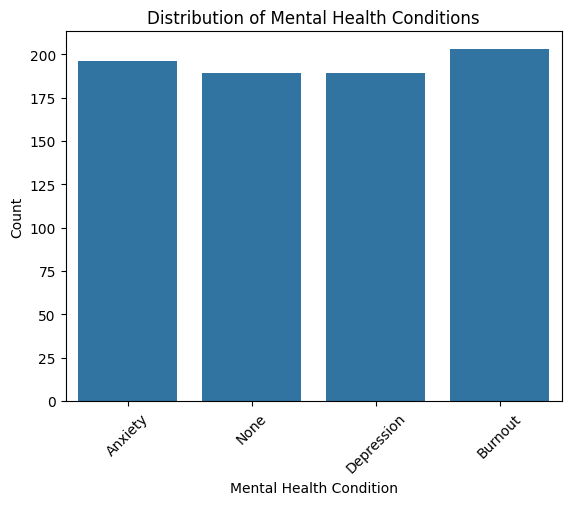

In [12]:
sns.countplot(x='Mental_Health_Condition', data=New_Impact_of_Remote_Work)
plt.title('Distribution of Mental Health Conditions')
plt.xlabel('Mental Health Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**A number of respondents are burned out as a result of their work.**

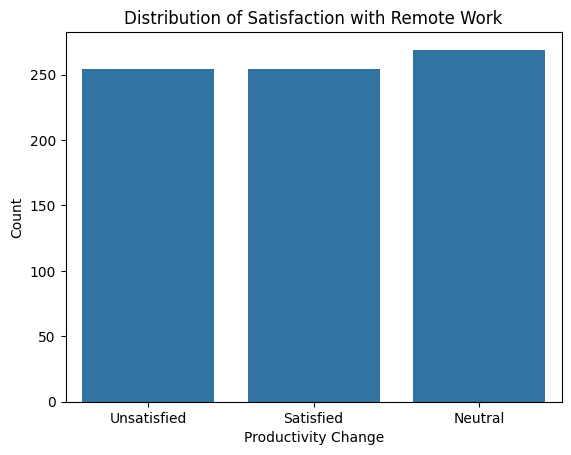

In [13]:
sns.countplot(x='Satisfaction_with_Remote_Work', data=New_Impact_of_Remote_Work)
plt.title('Distribution of Satisfaction with Remote Work')
plt.xlabel('Productivity Change')
plt.ylabel('Count')
plt.show()

**Little variation between the different levels of productivity change. About a third of respondents are unsatified with remote work and another third are satisfied. The last third being neutral on the subject.**

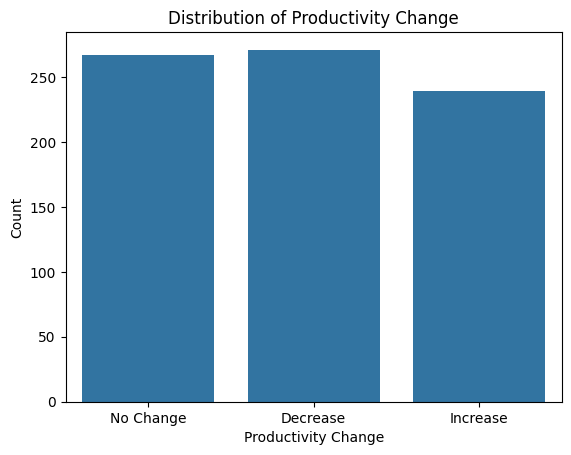

In [14]:
sns.countplot(x='Productivity_Change', data=New_Impact_of_Remote_Work)
plt.title('Distribution of Productivity Change')
plt.xlabel('Productivity Change')
plt.ylabel('Count')
plt.show()

**Little variation on the distribution of productivity change. Though the graph shows a higher number of respondents showing a decrease in productivity and no change in productivity, with the remaining of respondents showing an increase. The next step will be to filter the data to only show those that are remote and in office workers to see if theres any correlation between the variables posed with both sets of workers.**

In [15]:
#Filtering to distinguish onsite workers versus remote workers to be able to run comparisons
onsite_north_america = Impact_of_Remote_Work[(Impact_of_Remote_Work['Work_Location'] == 'Onsite') & (Impact_of_Remote_Work['Region'] == 'North America')] 
remote_north_america = Impact_of_Remote_Work[(Impact_of_Remote_Work['Work_Location'] == 'Remote') & (Impact_of_Remote_Work['Region'] == 'North America')]

In [16]:
onsite_north_america

,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,None,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America
7,42,Non-binary,Data Scientist,Manufacturing,6,Onsite,54,7,3,Medium,Depression,No,Decrease,5,Satisfied,4,None,Average,North America
21,26,Non-binary,Sales,Education,21,Onsite,54,12,3,Medium,Depression,No,Decrease,3,Unsatisfied,4,Daily,Poor,North America
26,36,Non-binary,Project Manager,Retail,30,Onsite,24,12,3,High,None,No,Decrease,4,Unsatisfied,4,None,Poor,North America
41,53,Male,Project Manager,IT,14,Onsite,29,13,2,Low,None,No,No Change,1,Unsatisfied,5,None,Good,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4912,42,Prefer not to say,Sales,Finance,6,Onsite,57,2,3,Medium,None,Yes,No Change,2,Unsatisfied,1,None,Poor,North America
4921,22,Female,HR,Consulting,2,Onsite,32,8,4,Low,None,No,Decrease,5,Neutral,2,None,Average,North America
4929,32,Male,Project Manager,Education,28,Onsite,20,12,2,Low,Depression,No,Increase,2,Neutral,4,None,Average,North America
4932,39,Non-binary,Project Manager,Education,33,Onsite,53,12,5,Low,Depression,Yes,Increase,1,Neutral,2,Daily,Poor,North America


In [17]:
remote_north_america

,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
24,56,Male,Sales,Finance,6,Remote,54,15,3,Low,Burnout,No,Increase,2,Neutral,4,Daily,Average,North America
29,59,Male,Software Engineer,Healthcare,34,Remote,25,15,2,High,Depression,Yes,No Change,3,Satisfied,1,Weekly,Poor,North America
32,45,Prefer not to say,Project Manager,Manufacturing,29,Remote,20,14,2,Medium,Anxiety,Yes,Decrease,5,Satisfied,5,Daily,Good,North America
33,48,Male,Software Engineer,Healthcare,27,Remote,26,9,3,Medium,Anxiety,Yes,No Change,5,Neutral,4,Daily,Average,North America
45,32,Male,Marketing,Retail,24,Remote,42,8,2,Medium,Burnout,No,No Change,2,Neutral,3,Daily,Poor,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4863,53,Prefer not to say,Sales,Healthcare,18,Remote,20,6,5,Low,Anxiety,Yes,Decrease,2,Neutral,3,Weekly,Poor,North America
4868,34,Prefer not to say,Project Manager,Retail,30,Remote,29,7,5,Low,None,No,Decrease,1,Satisfied,5,Daily,Good,North America
4881,37,Female,Sales,IT,24,Remote,57,5,2,Low,Anxiety,No,Increase,4,Neutral,3,Weekly,Poor,North America
4888,31,Female,Project Manager,Retail,22,Remote,33,6,1,Low,None,Yes,No Change,2,Satisfied,2,Weekly,Good,North America


**Next we will map the variables Mental Health Condition and Productivity Change to calculate  correlation coefficients.**

In [18]:
def map_categorical_to_numeric(New_Impact_of_Remote_Work): 
    
    """ 
    Maps categorical values in specified columns to numeric values. 
    Parameters: df (pd.DataFrame): The DataFrame containing the data to be mapped 
    Returns: pd.DataFrame: The DataFrame with mapped numeric columns 
    """ 
    
    # Define the mappings 
    productivity_change_mapping = {'Increase': 1, 'No Change': 0, 'Decrease': -1} 
    mental_health_mapping = {'Depression': 1, 'Anxiety': 0, 'Burnout': -1} 
   
    # Apply the mappings 
    New_Impact_of_Remote_Work['productivity_change_numeric'] = New_Impact_of_Remote_Work['Productivity_Change'].map(productivity_change_mapping) 
    New_Impact_of_Remote_Work['mental_health_condition_numeric'] = New_Impact_of_Remote_Work['Mental_Health_Condition'].map(mental_health_mapping)

    return New_Impact_of_Remote_Work

# Use the function to map categorical values to numeric
New_Impact_of_Remote_Work = map_categorical_to_numeric(New_Impact_of_Remote_Work) 

# Check the DataFrame 
New_Impact_of_Remote_Work

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_14786/3120891629.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  New_Impact_of_Remote_Work['productivity_change_numeric'] = New_Impact_of_Remote_Work['Productivity_Change'].map(productivity_change_mapping)
/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_14786/3120891629.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  New_Impact_of_Remote_Work['mental_health_condition_numeric'] = New_Impact_of_Remote_Work['Mental_Health_Condition

,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,...,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region,productivity_change_numeric,mental_health_condition_numeric
2,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,...,No,No Change,4,Unsatisfied,5,None,Poor,North America,0,0.0
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,...,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America,-1,NaN
7,42,Non-binary,Data Scientist,Manufacturing,6,Onsite,54,7,3,Medium,...,No,Decrease,5,Satisfied,4,None,Average,North America,-1,1.0
9,30,Female,HR,IT,28,Hybrid,57,6,1,Low,...,Yes,Decrease,2,Neutral,1,Weekly,Poor,North America,-1,1.0
13,51,Non-binary,Designer,Manufacturing,5,Hybrid,45,13,1,Low,...,No,Decrease,2,Satisfied,5,Weekly,Poor,North America,-1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4930,53,Female,HR,Retail,23,Hybrid,33,3,2,Low,...,No,No Change,1,Satisfied,3,Daily,Good,North America,0,-1.0
4932,39,Non-binary,Project Manager,Education,33,Onsite,53,12,5,Low,...,Yes,Increase,1,Neutral,2,Daily,Poor,North America,1,1.0
4938,23,Male,Software Engineer,Education,13,Remote,43,8,1,Medium,...,Yes,Increase,4,Satisfied,3,Weekly,Good,North America,1,NaN
4950,50,Non-binary,Project Manager,IT,26,Hybrid,50,7,4,Low,...,No,Decrease,3,Unsatisfied,1,Weekly,Good,North America,-1,-1.0


In [19]:
def calculate_correlations(New_Impact_of_Remote_Work, column_pairs): 
    """
    Calculates and prints the correlation for specified pairs of columns. 

    Parameters: 
    df (pd.DataFrame): The DataFrame containing the data 
    column_pairs (list of tuples): List of tuples, where each tuple contains two column names to calculate correlation between 
    
    Example: 
    column_pairs = [ 
    ('Work_Life_Balance_Rating', 'productivity_change_numeric'),
    ('mental_health_condition_numeric', 'productivity_change_numeric') 
    ]
    calculate_correlations(df, column_pairs)
    """ 
    for col1, col2 in column_pairs: 
        correlation = New_Impact_of_Remote_Work[col1].corr(New_Impact_of_Remote_Work[col2]) 
        print(f"The correlation between {col1} and {col2} is {correlation}")

# Define the column pairs for correlation calculation 
column_pairs = [ 
    ('Work_Life_Balance_Rating', 'productivity_change_numeric'),
    ('mental_health_condition_numeric', 'productivity_change_numeric') ]

#Print Coefficients
calculate_correlations(New_Impact_of_Remote_Work, column_pairs)

The correlation between Work_Life_Balance_Rating and productivity_change_numeric is -0.005640497334573244
The correlation between mental_health_condition_numeric and productivity_change_numeric is -0.001393852552846892


In [20]:
# Calculate average age, stress level, and work-life balance rating for each group to run metrics on variables that may have to do with mental well-being. 
metrics = { 'onsite_north_america': onsite_north_america.mean(numeric_only=True), 
           'remote_north_america': remote_north_america.mean(numeric_only=True) } 
metrics

{'onsite_north_america': Age                                41.297619
 Years_of_Experience                18.503968
 Hours_Worked_Per_Week              39.162698
 Number_of_Virtual_Meetings          7.757937
 Work_Life_Balance_Rating            3.015873
 Social_Isolation_Rating             3.027778
 Company_Support_for_Remote_Work     2.952381
 dtype: float64,
 'remote_north_america': Age                                41.056818
 Years_of_Experience                17.821970
 Hours_Worked_Per_Week              39.893939
 Number_of_Virtual_Meetings          8.083333
 Work_Life_Balance_Rating            2.875000
 Social_Isolation_Rating             3.011364
 Company_Support_for_Remote_Work     3.071970
 dtype: float64}

**Theres not much variance in the metrics for both onsite workers in North America and remote workers in North America. The following boxplot will more than likely not show much of a difference either.With this metric calculation we could only make an assumption that the stress levels between both groups could be the same.**
 

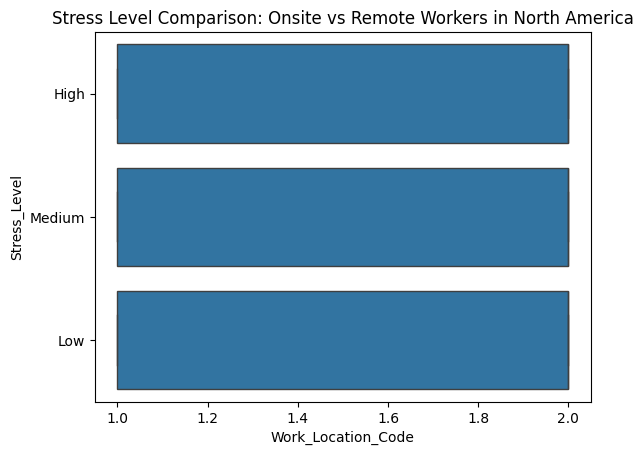

In [21]:
# Combine data for visualization 
New_Impact_of_Remote_Work = pd.concat([onsite_north_america.assign(Work_Location='Onsite'), remote_north_america.assign(Work_Location='Remote')])

# Box plot to compare stress levels plt.figure(figsize=(10, 6)) 
New_Impact_of_Remote_Work['Work_Location_Code'] = New_Impact_of_Remote_Work['Work_Location'].map({'Onsite': 1, 'Remote': 2})
sns.boxplot(x='Work_Location_Code', y='Stress_Level', data=New_Impact_of_Remote_Work)
plt.title('Stress Level Comparison: Onsite vs Remote Workers in North America') 
plt.show()


**As Kaggle runs on Python version 3.10, seasborn requires numerical values for the x- axis. To set the scene on this graph, 1.0 = onsite while 2.0 = remote. Seeing the visualization of these two variables, there is not a significant difference in stress levels between workers that are onsite or remote. At least for this particular data set. We could say that stress is the same no matter where the worker is stationed at.**
.

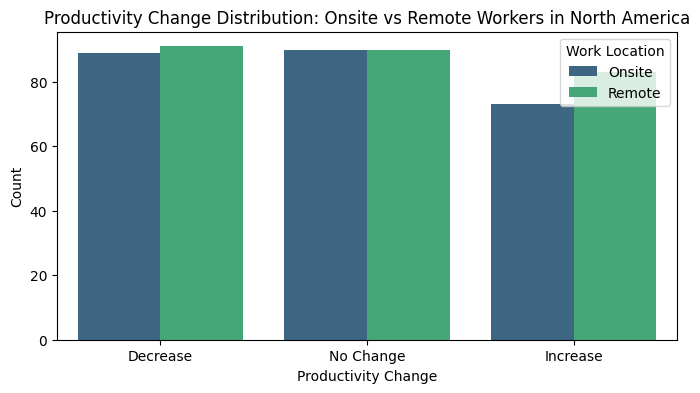

In [22]:
plt.figure(figsize=(8, 4)) 
sns.countplot(x='Productivity_Change', hue='Work_Location', data=New_Impact_of_Remote_Work, palette='viridis') 
plt.title('Productivity Change Distribution: Onsite vs Remote Workers in North America') 
plt.xlabel('Productivity Change') 
plt.ylabel('Count') 
plt.legend(title='Work Location') 
plt.show()

**As previously correlated, there is little difference in productivity change against remote or onsite. **